### Setup

In [1]:
# Setup: paths and imports
import sys
from pathlib import Path

import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.water_balance import compute_daily_water_balance, save_daily_water_balance
from src.crop_yield import compute_community_harvest, save_harvest_yields
from src.energy_balance import compute_daily_energy_balance, save_energy_balance
from src.plots import plot_water_balance, plot_energy_balance

SCENARIO_PATH = ROOT / 'scenarios' / 'scenario_base.yaml'

# Load scenario and resolve settings paths
with open(SCENARIO_PATH) as f:
    scenario = yaml.safe_load(f)

settings = {
    key: ROOT / scenario[key]
    for key in [
        'data_registry', 'community', 'farm_profiles',
        'water_systems', 'water_policy',
        'energy_system', 'energy_policy',
    ]
}

print(f"Scenario: {scenario['scenario_name']}")
print(f"Description: {scenario['description']}")
for key, path in settings.items():
    status = 'OK' if path.exists() else 'MISSING'
    print(f"  {key}: {path.name} [{status}]")


YEARS = 2

Scenario: baseline
Description: Baseline community — research-grade energy data, toy-grade water and building data
  data_registry: data_registry_base.yaml [OK]
  community: community_demands_base.yaml [OK]
  farm_profiles: farm_profile_base.yaml [OK]
  water_systems: water_systems_base.yaml [OK]
  water_policy: water_policy_base.yaml [OK]
  energy_system: energy_system_base.yaml [OK]
  energy_policy: energy_policy_base.yaml [OK]


### Calculate Harvest Yields

In [2]:
# Compute and save harvest yields for all fields, plantings, and years
harvest_df, harvests = compute_community_harvest(
    df,
    farm_profiles_path=settings['farm_profiles'],
    registry_path=settings['data_registry'],
)

print(f"Computed {len(harvests)} harvest events across {df['day'].min().year}-{df['day'].max().year}")
print(f"\nHarvest summary by crop:")
for crop, group in harvests.groupby('crop'):
    avg_yield = group['yield_kg_per_ha'].mean()
    total_kg = group['harvest_kg'].sum()
    print(f"  {crop}: {len(group)} harvests, avg {avg_yield:,.0f} kg/ha, total {total_kg:,.0f} kg")

# Save daily harvest yields CSV
output_path = save_harvest_yields(harvest_df, output_dir=ROOT / 'simulation')

harvest_days = (harvest_df['total_harvest_kg'] > 0).sum()
print(f"\nSaved {len(harvest_df)} days to {output_path.name}")
print(f"Days with harvests: {harvest_days}")
print(f"Total harvest: {harvest_df['total_harvest_kg'].sum():,.0f} kg")

NameError: name 'df' is not defined

### Daily Water Balance and Irrigation Energy Demands

In [3]:
# Compute daily water balance from scenario settings
df = compute_daily_water_balance(
    farm_profiles_path=settings['farm_profiles'],
    water_systems_path=settings['water_systems'],
    water_policy_path=settings['water_policy'],
    community_config_path=settings['community'],
    registry_path=settings['data_registry'],
)

water_output = save_daily_water_balance(df, output_dir=ROOT / 'simulation')

print(f"Computed {len(df)} days")
print(f"Date range: {df['day'].min().date()} to {df['day'].max().date()}")
print(f"Total irrigation demand: {df['irrigation_demand_m3'].sum():,.0f} m³")
print(f"Total community water:   {df['community_water_demand_m3'].sum():,.0f} m³")
print(f"Total deficit:           {df['deficit_m3'].sum():,.0f} m³")
print(f"Total energy:            {df['total_water_energy_kwh'].sum():,.1f} kWh")
print(f"Total cost:              ${df['total_water_cost'].sum():,.2f}")
print(f"\nSaved {len(df)} days to {water_output.name}")

Computed 5479 days
Date range: 2010-01-01 to 2024-12-31
Total irrigation demand: 1,495,671 m³
Total community water:   156,495 m³
Total deficit:           271 m³
Total energy:            2,162,080.2 kWh
Total cost:              $818,977.00

Saved 5479 days to daily_water_balance.csv


/Users/dpbirge/GITHUB/community-agri-pv/src/plots.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


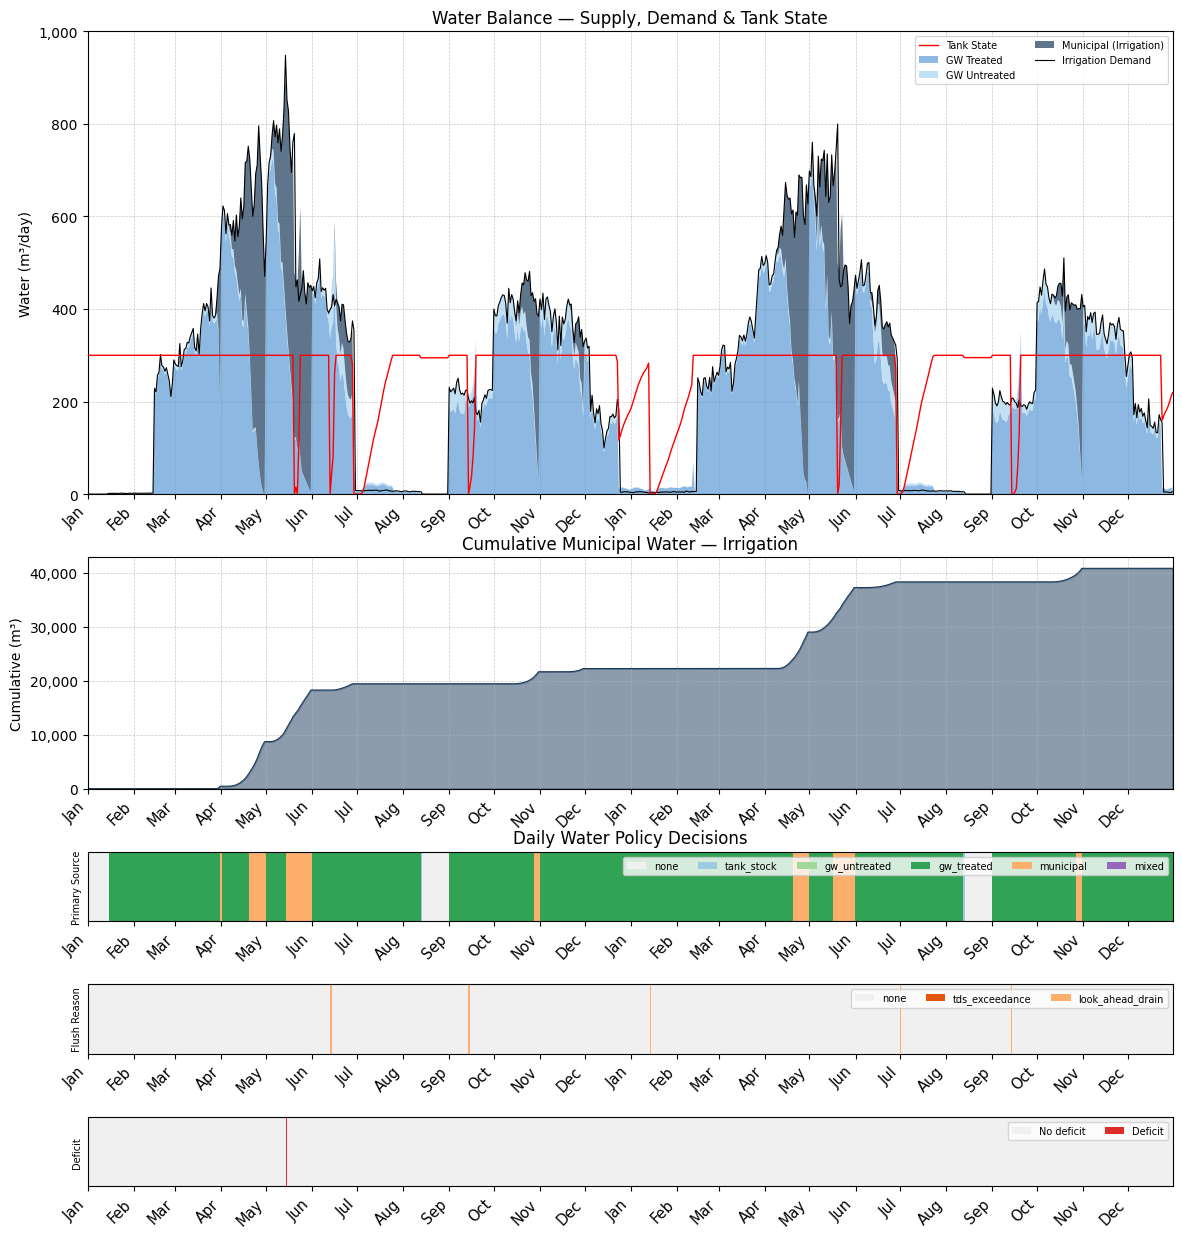

In [4]:
# Water balance: supply, demand, tank state, cumulative municipal, policy decisions
fig = plot_water_balance(df, years=YEARS)
plt.show()

### Energy System Balancing

In [5]:
# Compute and save daily energy balance (supply, demand, battery, grid, generator dispatch)
energy_df = compute_daily_energy_balance(
    energy_config_path=settings['energy_system'],
    energy_policy_path=settings['energy_policy'],
    community_config_path=settings['community'],
    farm_profiles_path=settings['farm_profiles'],
    registry_path=settings['data_registry'],
    water_balance_df=df,
)

print(f"Computed {len(energy_df)} days")
print(f"Date range: {energy_df['day'].min().date()} to {energy_df['day'].max().date()}")
print(f"Total demand:        {energy_df['total_demand_kwh'].sum():,.0f} kWh")
print(f"  Community bldg:    {energy_df['community_energy_demand_kwh'].sum():,.0f} kWh")
print(f"  Water systems:     {energy_df['water_energy_demand_kwh'].sum():,.0f} kWh")
print(f"Total renewable:     {energy_df['total_renewable_kwh'].sum():,.0f} kWh")
print(f"Grid import:         {energy_df['grid_import_kwh'].sum():,.0f} kWh")
print(f"Grid export:         {energy_df['grid_export_kwh'].sum():,.0f} kWh")
print(f"Generator:           {energy_df['generator_kwh'].sum():,.0f} kWh")
print(f"Curtailed:           {energy_df['curtailed_kwh'].sum():,.0f} kWh")
print(f"Deficit:             {energy_df['deficit_kwh'].sum():,.0f} kWh")
print(f"Total energy cost:   ${energy_df['total_energy_cost'].sum():,.2f}")

energy_output = save_energy_balance(energy_df, output_dir=ROOT / 'simulation')
print(f"\nSaved {len(energy_df)} days to {energy_output.name}")

Computed 5479 days
Date range: 2010-01-01 to 2024-12-31
Total demand:        6,211,097 kWh
  Community bldg:    4,049,017 kWh
  Water systems:     2,162,080 kWh
Total renewable:     7,809,944 kWh
Grid import:         221,687 kWh
Grid export:         1,874,732 kWh
Generator:           61,996 kWh
Curtailed:           -0 kWh
Deficit:             0 kWh
Total energy cost:   $27,018.62

Saved 5479 days to daily_energy_balance.csv


/Users/dpbirge/GITHUB/community-agri-pv/src/plots.py:493: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


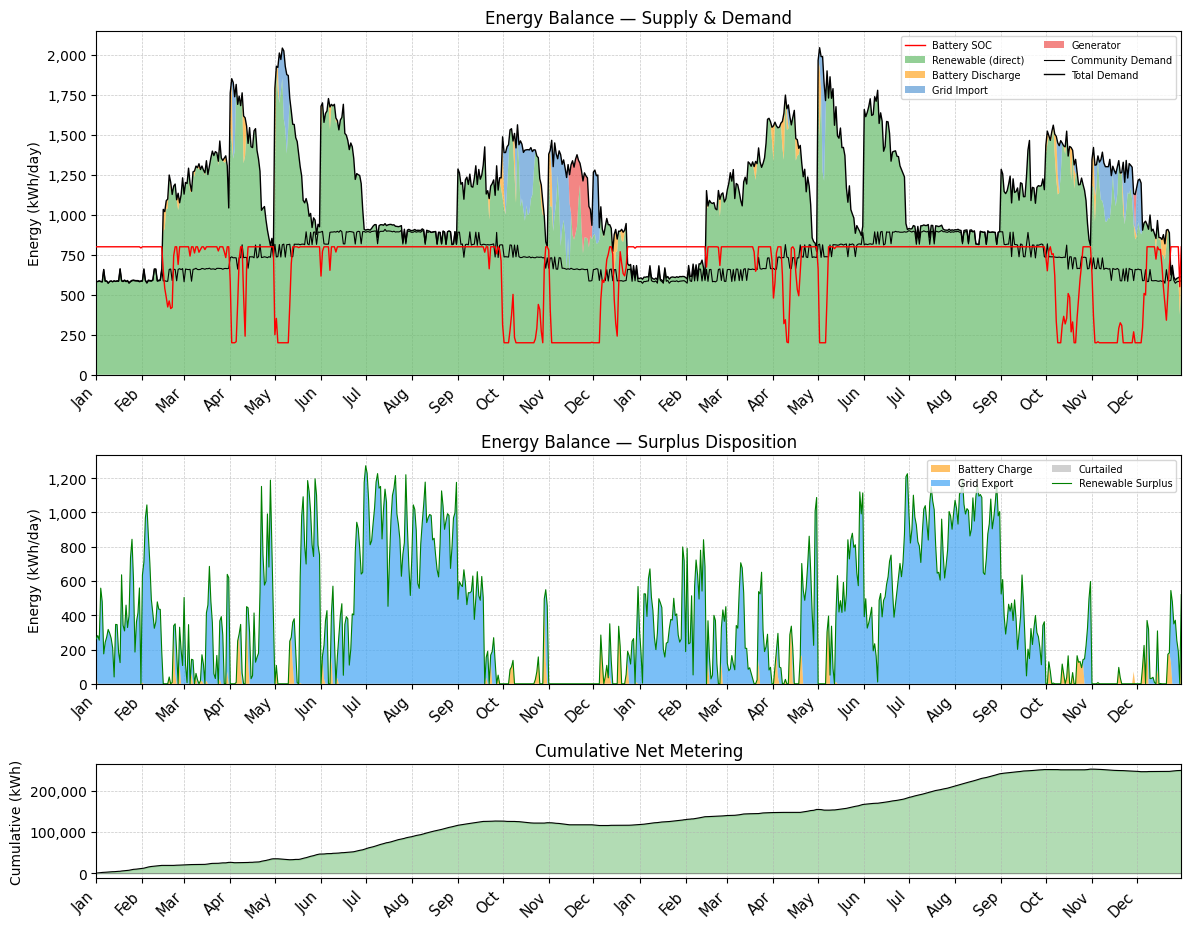

In [6]:
# Energy balance: supply stack, demand line, battery SOC, surplus disposition
fig = plot_energy_balance(energy_df, years=YEARS)
plt.show()

### Intraday Battery Adequacy w and w/o Irrigation Shifting | Annual Summary Statistics

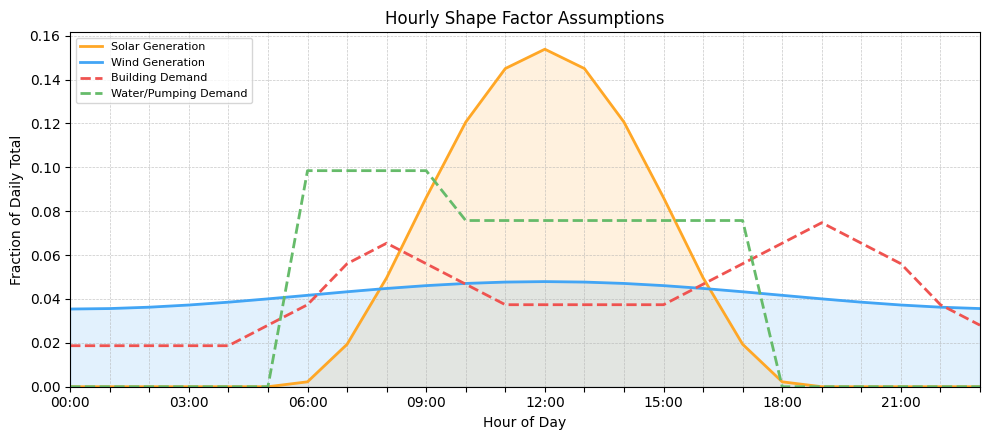

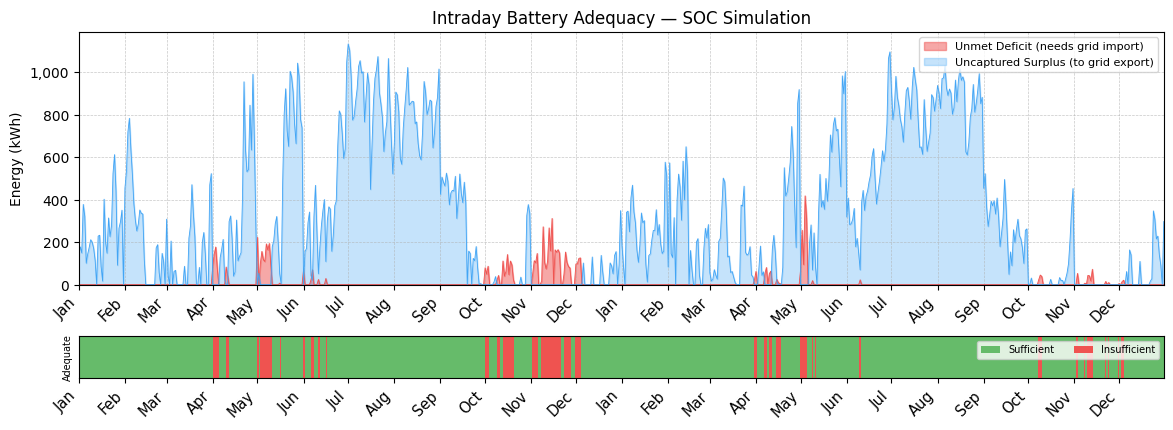

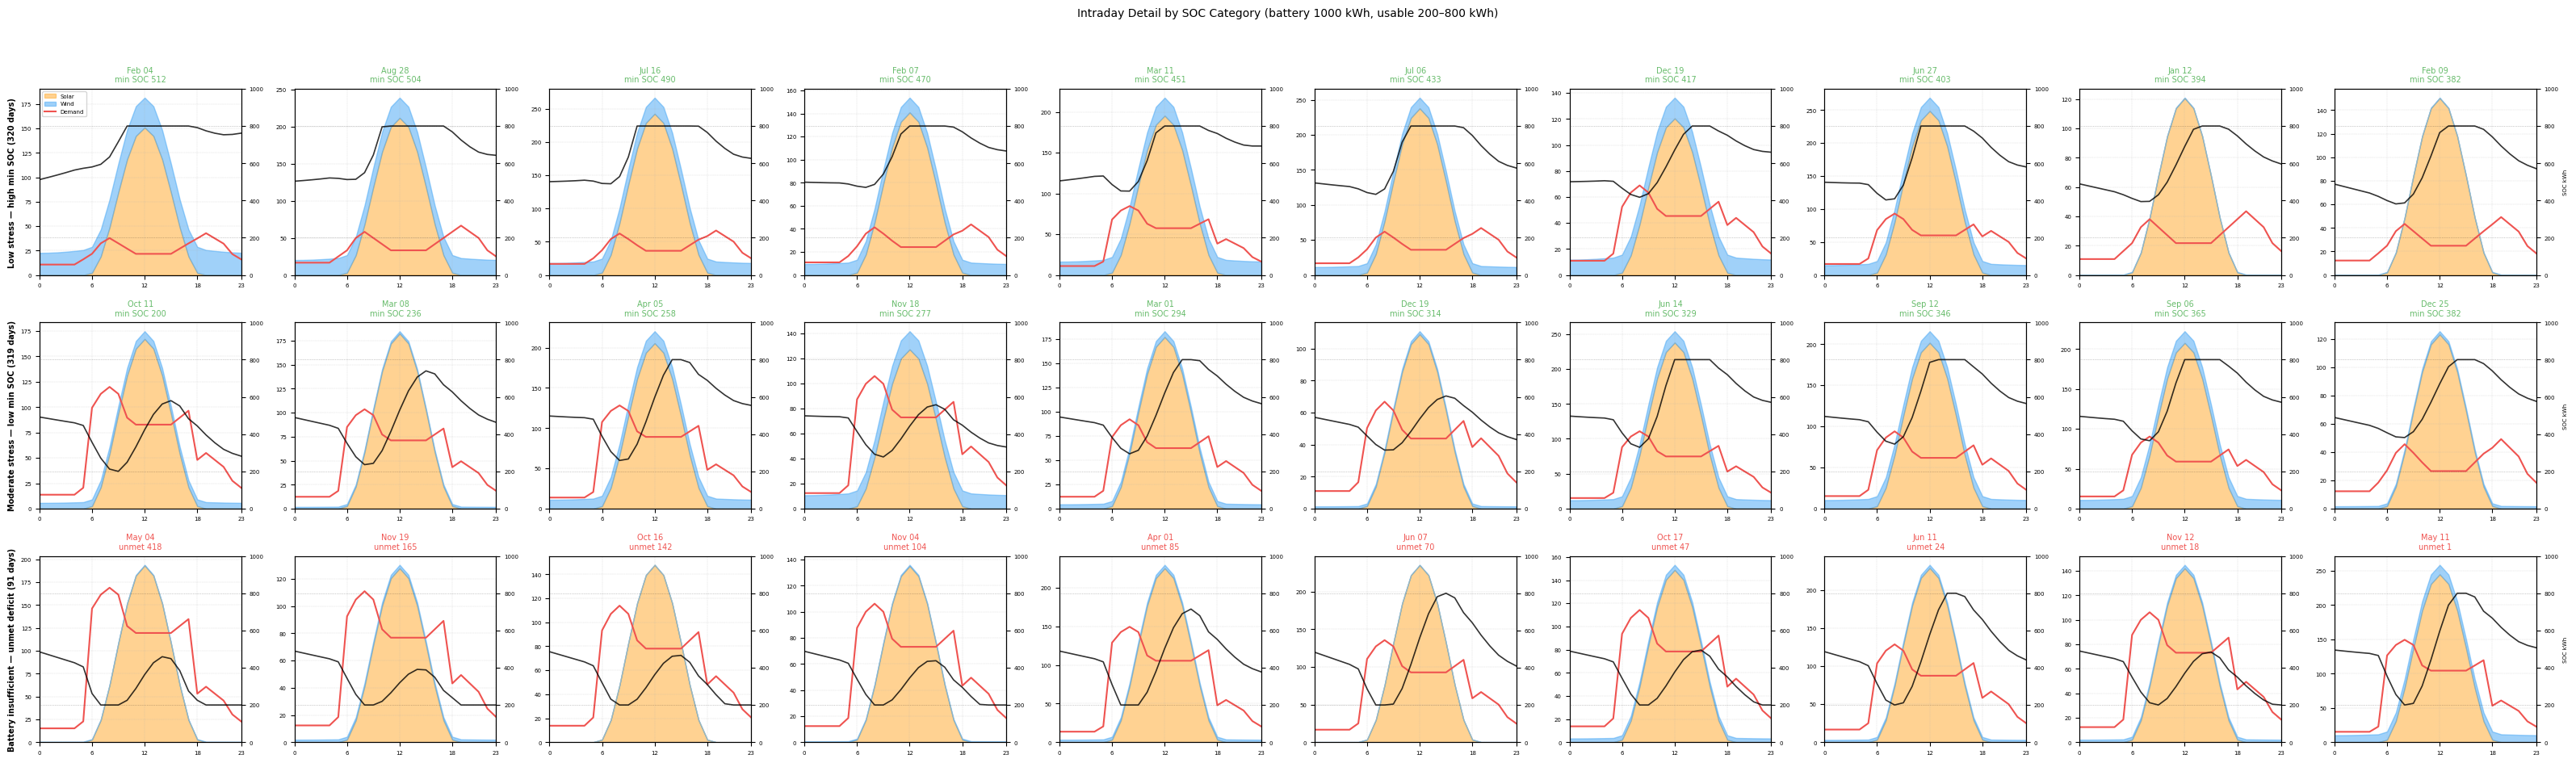

Intraday adequacy: 730 days analyzed, 91 with unmet deficit (12.5%)
Total unmet deficit: 8,350.6 kWh (would need grid import)
Total uncaptured surplus: 230,294.0 kWh (goes to grid export)
Usable battery capacity: 600 kWh


In [7]:
# Optional: estimate intraday battery adequacy using hourly shape factors
from src.intraday_estimate import (
    estimate_intraday_balance, plot_intraday_adequacy,
    plot_hourly_profiles, plot_intraday_detail,
)

_esys = yaml.safe_load(open(settings['energy_system']))
_epol = yaml.safe_load(open(settings['energy_policy']))

hourly_df, daily_df = estimate_intraday_balance(
    energy_balance_df=energy_df,
    battery_capacity_kwh=_esys['battery']['capacity_kwh'],
    soc_min=_epol['battery']['soc_min'],
    soc_max=_epol['battery']['soc_max'],
    years=YEARS,
)

fig = plot_hourly_profiles()
plt.show()

fig = plot_intraday_adequacy(daily_df)
plt.show()

fig = plot_intraday_detail(
    hourly_df, daily_df,
    battery_capacity_kwh=_esys['battery']['capacity_kwh'],
    soc_min=_epol['battery']['soc_min'],
    soc_max=_epol['battery']['soc_max'],
)
plt.show()

insufficient = daily_df['intraday_sufficient'].eq(False).sum()
print(f"Intraday adequacy: {len(daily_df)} days analyzed, "
      f"{insufficient} with unmet deficit ({insufficient/len(daily_df)*100:.1f}%)")
print(f"Total unmet deficit: {daily_df['unmet_deficit_kwh'].sum():,.1f} kWh "
      f"(would need grid import)")
print(f"Total uncaptured surplus: {daily_df['uncaptured_surplus_kwh'].sum():,.1f} kWh "
      f"(goes to grid export)")
print(f"Usable battery capacity: {daily_df['usable_capacity_kwh'].iloc[0]:,.0f} kWh")

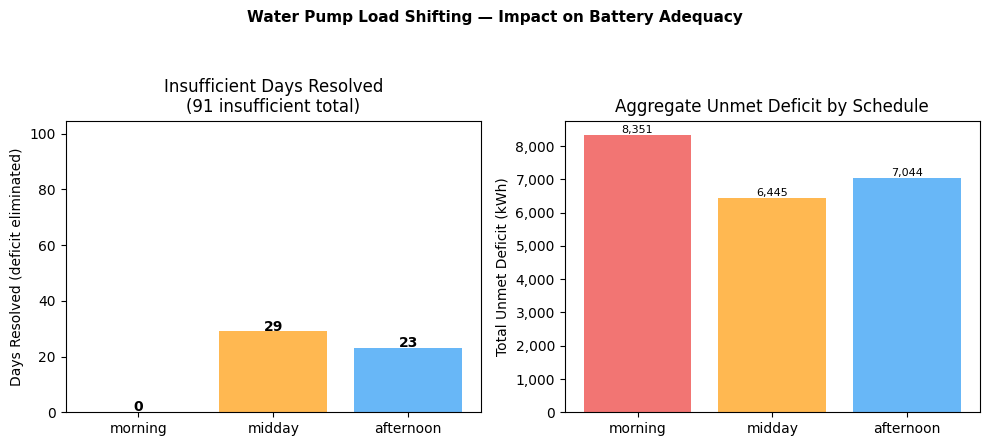

     morning:    8,351 kWh unmet,   0 days resolved,   0.0% reduction vs baseline
      midday:    6,445 kWh unmet,  29 days resolved,  22.8% reduction vs baseline
   afternoon:    7,044 kWh unmet,  23 days resolved,  15.6% reduction vs baseline

Best schedule per day:
best_schedule
midday       61
afternoon    21
morning       9


In [8]:
# Load-shifting analysis: test whether shifting water pump scheduling reduces unmet deficit
from src.intraday_estimate import analyze_load_shifting, plot_load_shifting

shift_df = analyze_load_shifting(
    energy_balance_df=energy_df,
    battery_capacity_kwh=_esys['battery']['capacity_kwh'],
    soc_min=_epol['battery']['soc_min'],
    soc_max=_epol['battery']['soc_max'],
    years=YEARS,
)

fig = plot_load_shifting(shift_df)
plt.show()

if not shift_df.empty:
    baseline_total = shift_df['baseline_unmet_kwh'].sum()
    best_col = {'morning': 'baseline_unmet_kwh', 'midday': 'midday_unmet_kwh',
                'afternoon': 'afternoon_unmet_kwh'}
    for sched in ['morning', 'midday', 'afternoon']:
        total = shift_df[best_col[sched]].sum()
        resolved = (shift_df[best_col[sched]] < 0.01).sum()
        pct = (1 - total / baseline_total) * 100 if baseline_total > 0 else 0
        print(f"  {sched:>10}: {total:>8,.0f} kWh unmet, "
              f"{resolved:>3} days resolved, "
              f"{pct:>5.1f}% reduction vs baseline")
    print(f"\nBest schedule per day:")
    print(shift_df['best_schedule'].value_counts().to_string())
else:
    print("No insufficient days — load shifting not needed.")

In [9]:
# Annual energy and water summary statistics - not printed by default

"""
import pandas as pd

annual = df.groupby(df['day'].dt.year).agg(
    irrigation_demand_m3=('irrigation_demand_m3', 'sum'),
    community_water_m3=('community_water_demand_m3', 'sum'),
    total_delivered_m3=('irrigation_delivered_m3', 'sum'),
    deficit_m3=('deficit_m3', 'sum'),
    gw_untreated_m3=('gw_untreated_to_tank_m3', 'sum'),
    gw_treated_m3=('gw_treated_to_tank_m3', 'sum'),
    municipal_irrig_m3=('municipal_to_tank_m3', 'sum'),
    total_water_energy_kwh=('total_water_energy_kwh', 'sum'),
    total_cost_usd=('total_water_cost', 'sum'),
).round(1)

annual.index.name = 'year'
annual
"""

"""
energy_annual = energy_df.groupby(energy_df['day'].dt.year).agg(
    community_demand_kwh=('community_energy_demand_kwh', 'sum'),
    water_demand_kwh=('water_energy_demand_kwh', 'sum'),
    total_demand_kwh=('total_demand_kwh', 'sum'),
    total_renewable_kwh=('total_renewable_kwh', 'sum'),
    renewable_consumed_kwh=('renewable_consumed_kwh', 'sum'),
    battery_charge_kwh=('battery_charge_kwh', 'sum'),
    battery_discharge_kwh=('battery_discharge_kwh', 'sum'),
    grid_import_kwh=('grid_import_kwh', 'sum'),
    grid_export_kwh=('grid_export_kwh', 'sum'),
    generator_kwh=('generator_kwh', 'sum'),
    curtailed_kwh=('curtailed_kwh', 'sum'),
    deficit_kwh=('deficit_kwh', 'sum'),
    total_energy_cost=('total_energy_cost', 'sum'),
).round(1)

energy_annual.index.name = 'year'
energy_annual
"""

"\nenergy_annual = energy_df.groupby(energy_df['day'].dt.year).agg(\n    community_demand_kwh=('community_energy_demand_kwh', 'sum'),\n    water_demand_kwh=('water_energy_demand_kwh', 'sum'),\n    total_demand_kwh=('total_demand_kwh', 'sum'),\n    total_renewable_kwh=('total_renewable_kwh', 'sum'),\n    renewable_consumed_kwh=('renewable_consumed_kwh', 'sum'),\n    battery_charge_kwh=('battery_charge_kwh', 'sum'),\n    battery_discharge_kwh=('battery_discharge_kwh', 'sum'),\n    grid_import_kwh=('grid_import_kwh', 'sum'),\n    grid_export_kwh=('grid_export_kwh', 'sum'),\n    generator_kwh=('generator_kwh', 'sum'),\n    curtailed_kwh=('curtailed_kwh', 'sum'),\n    deficit_kwh=('deficit_kwh', 'sum'),\n    total_energy_cost=('total_energy_cost', 'sum'),\n).round(1)\n\nenergy_annual.index.name = 'year'\nenergy_annual\n"